## 1) Setup

In [1]:

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV, Ridge, LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.set_printoptions(suppress=True, linewidth=140)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 120)

RANDOM_SEED = 1337 #fixed seed for deterministic splits
N_SPLITS = 5 #using a 5-fold cross validation
USE_PCA = False


## 2) Paths and file upload

In [18]:
DATA_DIR = "/content"
PATH_RNA = f"{DATA_DIR}/HEK293T_RNA_CLR_wide.csv"
PATH_TE  = f"{DATA_DIR}/HEK293T_TE_CLR_wide.csv"
PATH_TX2GENE = f"{DATA_DIR}/tx2gene.csv"

OUT_DIR = os.path.join(DATA_DIR, "week3_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print("Data dir:", DATA_DIR)
print("Outputs →", OUT_DIR)

try:
    from google.colab import files
    print("Upload RNA CSV, TE CSV, tx2gene CSV (if available), Counts Excel, and MetaData Excel files.")
    # upload files directly
    uploaded = files.upload()
    print("Uploaded:", list(uploaded.keys()))
except ImportError:
    print("An error occurred during file upload:")
except Exception as e:
    print(f"An error occurred during file upload: {e}")

Data dir: /content
Outputs → /content/week3_outputs
Upload RNA CSV, TE CSV, tx2gene CSV (if available), Counts Excel, and MetaData Excel files.


Saving MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx to MCE_Bioactive_Compounds_HEK293T_10μM_MetaData (1).xlsx
Saving MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx to MCE_Bioactive_Compounds_HEK293T_10μM_Counts (1).xlsx
Uploaded: ['MCE_Bioactive_Compounds_HEK293T_10μM_MetaData (1).xlsx', 'MCE_Bioactive_Compounds_HEK293T_10μM_Counts (1).xlsx']


## 3) Helper functions for cleaning

In [3]:
def drop_index_like(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=["Unnamed: 0"], errors="ignore")

def pick_id_col(cols) -> str:
    for c in ["gene", "transcript", "feature_id", "id"]:
        if c in cols: return c
    return cols[0]

def safe_pearsonr(a: np.ndarray, b: np.ndarray) -> float:
    if np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    r = np.corrcoef(a, b)[0,1]
    return float(r) if np.isfinite(r) else float("nan")

def eval_per_gene(y_true: np.ndarray, y_pred: np.ndarray, ids) -> pd.DataFrame:
    rows = []
    for j, gid in enumerate(ids):
        yt = y_true[:, j]; yp = y_pred[:, j]
        r  = safe_pearsonr(yt, yp)
        ss_res = np.sum((yt - yp)**2)
        ss_tot = np.sum((yt - np.mean(yt))**2)
        r2 = float("nan") if ss_tot == 0 else 1.0 - (ss_res/ss_tot)
        mae = mean_absolute_error(yt, yp)
        rmse = mean_squared_error(yt, yp)
        rows.append({"id": gid, "pearson_r": r, "r2": r2, "mae": mae, "rmse": rmse})
    return pd.DataFrame(rows)

def to_gene_symbols(df: pd.DataFrame, id_col: str, tx2gene: pd.DataFrame=None) -> pd.DataFrame:
    if tx2gene is None or not set(["transcript","gene_symbol"]).issubset(tx2gene.columns):
        out = df.copy(); out["gene_symbol"] = out[id_col].astype(str); return out
    if id_col.lower() != "transcript":
        out = df.copy(); out["gene_symbol"] = out[id_col].astype(str); return out
    out = df.merge(tx2gene[["transcript","gene_symbol"]], left_on=id_col, right_on="transcript", how="left")
    out["gene_symbol"] = out["gene_symbol"].fillna(out[id_col].astype(str))
    out = out.drop(columns=["transcript_y"], errors="ignore")
    out = out.rename(columns={"transcript_x":"transcript"})
    return out

def rps_rpl_mask(symbols: pd.Series) -> pd.Series:
    s = symbols.fillna("").str.upper()
    return s.str.startswith("RPS") | s.str.startswith("RPL")

## 4) Load and align RNA/TE matrices

In [4]:
rna = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
te  = drop_index_like(pd.read_csv(f"{DATA_DIR}/TE_HEK293T.csv"))

id_col_rna = pick_id_col(rna.columns.tolist())
id_col_te  = pick_id_col(te.columns.tolist())

sample_cols = [c for c in rna.columns if c != id_col_rna and c in te.columns]
rna = rna[[id_col_rna] + sample_cols].copy()
te  = te [[id_col_te ] + sample_cols].copy()

common_ids = sorted(set(rna[id_col_rna]) & set(te[id_col_te]))
rna = rna[rna[id_col_rna].isin(common_ids)].sort_values(id_col_rna).reset_index(drop=True)
te  = te [te [id_col_te ].isin(common_ids)].sort_values(id_col_te ).reset_index(drop=True)

rna = rna.rename(columns={id_col_rna: "feature_id"})
te  = te .rename(columns={id_col_te:  "feature_id"})

print("RNA shape:", rna.shape)
print("TE  shape:", te.shape)
print("Samples:", len(sample_cols))

RNA shape: (8433, 99)
TE  shape: (8433, 99)
Samples: 98


## 5) Add gene symbols and build ML matrices

In [5]:
tx2gene = None
if os.path.exists(PATH_TX2GENE):
    try:
        tx2gene = pd.read_csv(PATH_TX2GENE)
    except Exception as e:
        print("Warning: could not read tx2gene.csv:", e)

rna_sym = to_gene_symbols(rna, "feature_id", tx2gene)
te_sym  = to_gene_symbols(te,  "feature_id", tx2gene)

genes = rna["feature_id"].tolist()
gene_symbols = rna_sym["gene_symbol"].tolist()

X = rna[sample_cols].T.values  # RNA
Y = te [sample_cols].T.values  # TE

print("Matrix shapes — X:", X.shape, "Y:", Y.shape)


Matrix shapes — X: (98, 8433) Y: (98, 8433)


Lasso

In [8]:
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

def cv_predict_vector(X, y, alphas=None, n_splits=5, random_state=1337):
    if alphas is None:
        alphas = np.logspace(-3, 1, 20)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    yhat = np.empty_like(y, dtype=float)
    chosen, nnz = [], []
    for tr, te in kf.split(X):
        lcv = LassoCV(alphas=alphas, cv=5, random_state=random_state, n_jobs=-1, max_iter=10000)
        lcv.fit(X[tr], y[tr])
        yhat[te] = lcv.predict(X[te])
        chosen.append(lcv.alpha_)
        nnz.append(np.count_nonzero(lcv.coef_))
    return yhat, np.array(chosen), np.array(nnz)

# Masks (expects gene_symbols: array-like of gene names)
sym = pd.Series(gene_symbols).str.upper()
rps_mask = sym.str.startswith("RPS").values
rpl_mask = sym.str.startswith("RPL").values

# Cluster targets (mean TE across genes in cluster)
TE_RPS = np.nanmean(Y[:, rps_mask], axis=1)
TE_RPL = np.nanmean(Y[:, rpl_mask], axis=1)

# Run CV prediction
Yhat_RPS, alphas_rps, nnz_rps = cv_predict_vector(X, TE_RPS)
Yhat_RPL, alphas_rpl, nnz_rpl = cv_predict_vector(X, TE_RPL)

# Compact summary
def summarize(y, yhat, name):
    r = np.corrcoef(y, yhat)[0, 1] if (np.std(y)>0 and np.std(yhat)>0) else np.nan
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    print(f"{name}: r={r:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")

summarize(TE_RPS, Yhat_RPS, "RPS cluster")
summarize(TE_RPL, Yhat_RPL, "RPL cluster")
print("Median alpha (RPS, RPL):", float(np.median(alphas_rps)), float(np.median(alphas_rpl)))
print("Median non-zero features (RPS, RPL):", int(np.median(nnz_rps)), int(np.median(nnz_rpl)))

RPS cluster: r=0.964, MAE=0.167, RMSE=0.240
RPL cluster: r=0.969, MAE=0.192, RMSE=0.268
Median alpha (RPS, RPL): 0.029763514416313176 0.018329807108324356
Median non-zero features (RPS, RPL): 14 29


In [9]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Removed: from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas

# Fit final Lasso model on full data (no scaling)
def fit_full_lasso(X_data, y, alpha):
    # Drop samples with NaN in y
    nan_mask = np.isnan(y)
    X_clean = X_data[~nan_mask]
    y_clean = y[~nan_mask]

    if len(y_clean) == 0:
        print("Warning: No non-NaN samples found for this target vector. Cannot fit model.")
        return None, None # Return None for model and scaler

    # Removed: scaler = StandardScaler().fit(X_clean)
    # Removed: Xs = scaler.transform(X_clean)
    # Use X_clean directly without scaling
    model = LassoCV(alphas=[alpha], cv=min(5, len(y_clean)), random_state=RANDOM_SEED, max_iter=10000).fit(X_clean, y_clean)
    return model, None # Return None for scaler as it's not used

# Load and transpose RNA data explicitly for this cell
rna_for_lasso = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
id_col_rna_for_lasso = pick_id_col(rna_for_lasso.columns.tolist())
sample_cols_for_lasso = [c for c in rna_for_lasso.columns if c != id_col_rna_for_lasso]
X_lasso = rna_for_lasso[sample_cols_for_lasso].T.values # Samples as rows

# Use median alpha values from cross-validation results
alpha_rps = float(np.nanmedian(alphas_rps))
alpha_rpl = float(np.nanmedian(alphas_rpl))

lasso_rps, scaler_rps = fit_full_lasso(X_lasso, TE_RPS, alpha_rps)
lasso_rpl, scaler_rpl = fit_full_lasso(X_lasso, TE_RPL, alpha_rpl)

# Top features by absolute weight
def top_features(model, k=20):
    if model is None:
        return pd.DataFrame(columns=["gene_id", "gene_symbol", "weight"])
    w = model.coef_
    # Need gene names corresponding to X_lasso, not the reduced X
    rna_for_features = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
    id_col_rna_for_features = pick_id_col(rna_for_features.columns.tolist())
    rna_for_features = rna_for_features.rename(columns={id_col_rna_for_features: "feature_id"})
    tx2gene_for_features = None
    if os.path.exists(PATH_TX2GENE):
        try:
            tx2gene_for_features = pd.read_csv(PATH_TX2GENE)
        except Exception as e:
            print("Warning: could not read tx2gene.csv:", e)
    rna_sym_for_features = to_gene_symbols(rna_for_features, "feature_id", tx2gene_for_features)
    genes_for_features = rna_for_features["feature_id"].tolist()
    gene_symbols_for_features = rna_sym_for_features["gene_symbol"].tolist()

    idx = np.argsort(-np.abs(w))[:k]
    return pd.DataFrame({
        "gene_id": [genes_for_features[i] for i in idx],
        "gene_symbol": [gene_symbols_for_features[i] for i in idx],
        "weight": w[idx]
    })

print("\nTop RNA features for RPS cluster:\n", top_features(lasso_rps).to_string(index=False))
print("\nTop RNA features for RPL cluster:\n", top_features(lasso_rpl).to_string(index=False))


Top RNA features for RPS cluster:
  gene_id gene_symbol    weight
   RPL10       RPL10 -0.471598
    RPL4        RPL4 -0.224940
  EEF1A1      EEF1A1 -0.077805
   FOSL2       FOSL2  0.037908
   CHAC1       CHAC1  0.031155
EPM2AIP1    EPM2AIP1 -0.029779
   HSPB1       HSPB1 -0.023778
    LDAH        LDAH  0.013874
   DECR1       DECR1  0.012914
  RNASEK      RNASEK -0.011497
    NAAA        NAAA  0.011151
   DUSP5       DUSP5  0.010838
   HHLA3       HHLA3 -0.009589
  S100A4      S100A4 -0.004351
  MT-ND5      MT-ND5 -0.000000
 MT-ND4L     MT-ND4L -0.000000
 MT-ATP6     MT-ATP6 -0.000000
 MT-ATP8     MT-ATP8 -0.000000
  MT-CO2      MT-CO2 -0.000000
   VAMP7       VAMP7 -0.000000

Top RNA features for RPL cluster:
 gene_id gene_symbol    weight
  RPL10       RPL10 -0.496531
   RPL4        RPL4 -0.307308
  FOSL2       FOSL2  0.082559
  RPS29       RPS29 -0.075645
  RPL28       RPL28 -0.058885
  CHAC1       CHAC1  0.054376
   MLH1        MLH1 -0.042942
 TPRG1L      TPRG1L  0.034714
  SPOPL

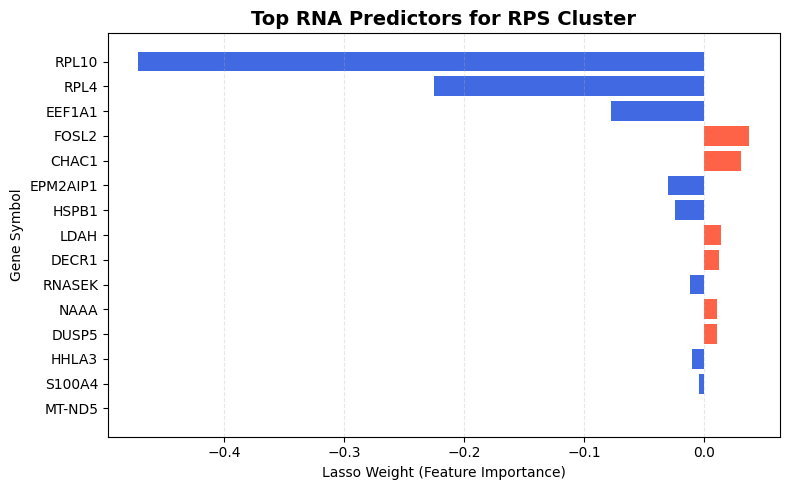

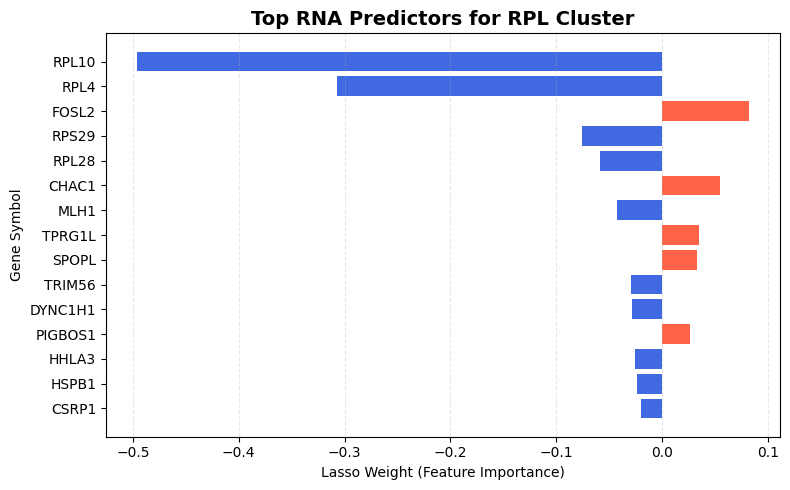

In [10]:
def plot_lasso_weights(df, title, top_k=15):
    """
    Create a horizontal barplot of the top_k most important RNA features.
    Red = positive weight (higher RNA, higher cluster TE)
    Blue = negative weight (higher RNA, lower cluster TE)
    """
    # Sort by absolute weight, take top_k
    df_sorted = df.reindex(df["weight"].abs().sort_values(ascending=False).index)[:top_k]

    plt.figure(figsize=(8, 5))
    colors = df_sorted["weight"].apply(lambda x: "tomato" if x > 0 else "royalblue")

    plt.barh(df_sorted["gene_symbol"], df_sorted["weight"], color=colors)
    plt.gca().invert_yaxis()  # most important feature on top

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Lasso Weight (Feature Importance)")
    plt.ylabel("Gene Symbol")
    plt.grid(alpha=0.3, linestyle="--", axis="x")
    plt.tight_layout()
    plt.show()

top_rps_df = top_features(lasso_rps, k=20)
top_rpl_df = top_features(lasso_rpl, k=20)

plot_lasso_weights(top_rps_df, "Top RNA Predictors for RPS Cluster", top_k=15)
plot_lasso_weights(top_rpl_df, "Top RNA Predictors for RPL Cluster", top_k=15)

## Vector-output MultiTask Lasso, predicting TE for all RPS/RPL genes  jointly

In [ ]:
import pandas as pd, numpy as np
from sklearn.linear_model import MultiTaskLasso, MultiTaskLassoCV
from sklearn.metrics import mean_squared_error

# ---------- helpers ----------
def to_numeric(df): return df.apply(pd.to_numeric, errors="coerce")
def fill_cols(df):  return df.fillna(df.mean(axis=0))
def clr(df):        # rows = samples, cols = genes
    df = df.clip(lower=1e-6)
    gm = np.exp(np.log(df).mean(axis=1))
    return np.log(df.div(gm, axis=0))

# ---------- load HEK training tables (already CLR-normalized) ----------
rna_raw = pd.read_csv('/content/RNA_HEK293T.csv')
te_raw  = pd.read_csv('/content/TE_HEK293T.csv')

id_rna = 'transcript' if 'transcript' in rna_raw.columns else rna_raw.columns[0]
id_te  = 'transcript' if 'transcript' in te_raw.columns  else te_raw.columns[0]
rna_raw = rna_raw.set_index(id_rna)
te_raw  = te_raw.set_index(id_te)

samples = rna_raw.columns.intersection(te_raw.columns)
genes   = rna_raw.index.intersection(te_raw.index)

rna = to_numeric(rna_raw.loc[genes, samples])
te  = to_numeric(te_raw .loc[genes, samples])

# ---------- masks ----------
sym        = pd.Index(genes).str.upper()
is_ribo    = sym.str.startswith('RPS') | sym.str.startswith('RPL')     # Y targets
is_nonribo = ~is_ribo                                                  # X predictors

X_train_all = rna.loc[is_nonribo]   # genes×samples
Y_train_all = te .loc[is_ribo]      # genes×samples

# ---------- build sklearn matrices ----------
X_mat = fill_cols(X_train_all).T.values.astype(np.float32)  # samples×features
Y_mat = fill_cols(Y_train_all).T.values.astype(np.float32)  # samples×targets
feature_names = np.array(X_train_all.index)                 # non-RPS/RPL only
target_names  = np.array(Y_train_all.index)                 # RPS/RPL only

# ---------- train (fast) ----------
USE_CV = False
ALPHA  = 0.01
if USE_CV:
    model = MultiTaskLassoCV(cv=5, n_alphas=50, max_iter=3000, tol=1e-3, random_state=1337, n_jobs=-1).fit(X_mat, Y_mat)
    alpha_star = float(model.alpha_)
else:
    model = MultiTaskLasso(alpha=ALPHA, max_iter=3000, tol=1e-3).fit(X_mat, Y_mat)
    alpha_star = ALPHA

rmse = np.sqrt(mean_squared_error(Y_mat, model.predict(X_mat)))
print(f"Train RMSE: {rmse:.3f} | alpha*: {alpha_star}")



===== MultiTask Lasso Model Summary =====
Targets (RPS/RPL genes): 87
Predictor features (non-ribosomal genes): 8346
Sparsity (fraction of zeros): 0.0000
Median non-zero predictors per ribosomal gene: 8346.0
Predictors used in at least 5 ribosomal genes: 8346

===== Per-Target RMSE (first few) =====
RPL22: RMSE=0.222
RPL11: RMSE=0.324
RPS6KA1: RMSE=0.347
RPS8: RMSE=0.632
RPL5: RMSE=0.869
RPS27: RMSE=1.180
RPS6KC1: RMSE=1.927
RPS7: RMSE=1.825
RPS27A: RMSE=2.126
RPL31: RMSE=2.376

Mean per-target RMSE: 9.299
Median per-target RMSE: 9.581

===== Top 25 MultiTask Predictors (by mean |coef|) =====


,gene,mean_abs_coef,nonzero_count
0,NOC2L,151.195038,87
1,INTS11,105.452026,87
2,DVL1,93.990318,87
3,AURKAIP1,64.768982,87
4,CDK11B,39.558094,87
5,AGRN,36.456326,87
6,PUSL1,31.827326,87
7,MIB2,30.463999,87
8,CCNL2,26.818485,87
9,SLC35E2B,23.736103,87


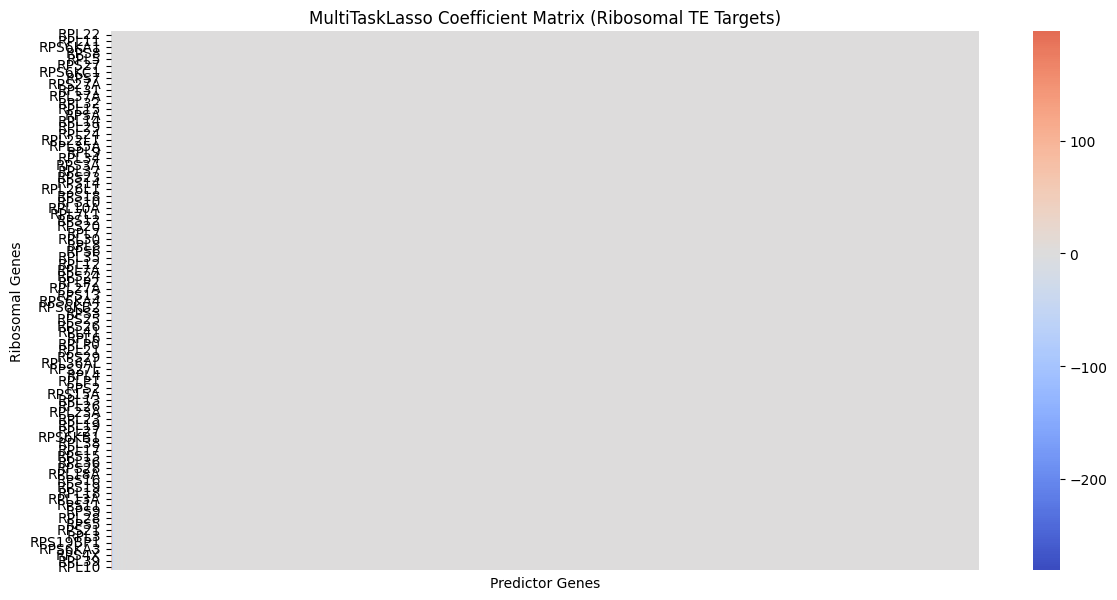

/tmp/ipython-input-3516295611.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_summary["mean_abs_coef"],


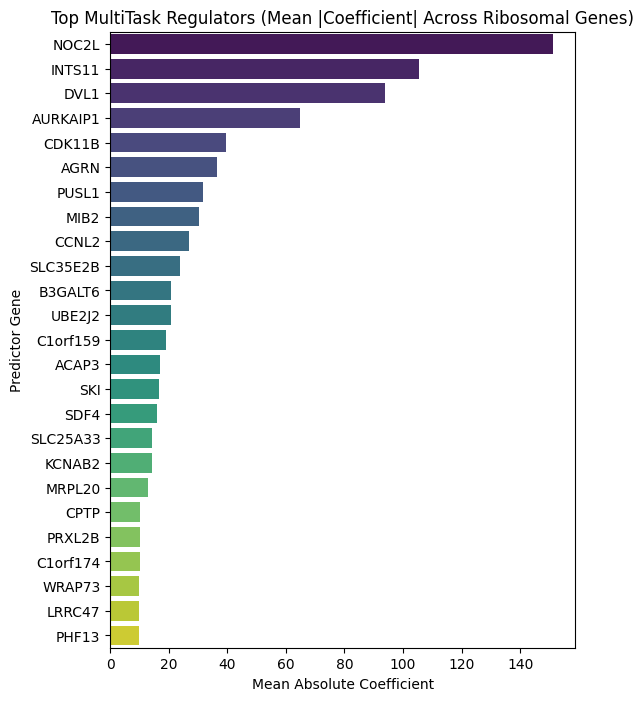

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------------
# 1. Basic model info
# ---------------------------------------------------------
coef_matrix = model.coef_          # shape: [n_targets, n_features]
n_targets, n_features = coef_matrix.shape

nonzero_per_target = np.sum(coef_matrix != 0, axis=1)   # per RPS/RPL gene
nonzero_per_feature = np.sum(coef_matrix != 0, axis=0)  # per predictor gene

print("\n===== MultiTask Lasso Model Summary =====")
print(f"Targets (RPS/RPL genes): {n_targets}")
print(f"Predictor features (non-ribosomal genes): {n_features}")
print(f"Sparsity (fraction of zeros): {np.mean(coef_matrix==0):.4f}")

print(f"Median non-zero predictors per ribosomal gene: {np.median(nonzero_per_target)}")
print(f"Predictors used in at least 5 ribosomal genes: {(nonzero_per_feature >= 5).sum()}")

# ---------------------------------------------------------
# 2. Per-target prediction errors
# ---------------------------------------------------------
Y_pred = model.predict(X_mat)

per_target_rmse = np.sqrt(np.mean((Y_mat - Y_pred)**2, axis=0))

print("\n===== Per-Target RMSE (first few) =====")
for name, err in zip(target_names[:10], per_target_rmse[:10]):
    print(f"{name}: RMSE={err:.3f}")

print(f"\nMean per-target RMSE: {per_target_rmse.mean():.3f}")
print(f"Median per-target RMSE: {np.median(per_target_rmse):.3f}")

# ---------------------------------------------------------
# 3. Feature influence summary across all ribosomal genes
# ---------------------------------------------------------
mean_abs_coef = np.mean(np.abs(coef_matrix), axis=0)
top_idx = np.argsort(mean_abs_coef)[::-1][:25]

feature_summary = pd.DataFrame({
    "gene": feature_names[top_idx],
    "mean_abs_coef": mean_abs_coef[top_idx],
    "nonzero_count": nonzero_per_feature[top_idx]
})

print("\n===== Top 25 MultiTask Predictors (by mean |coef|) =====")
display(feature_summary)

# ---------------------------------------------------------
# 4. Heatmap of coefficient matrix (for visualization)
# ---------------------------------------------------------
plt.figure(figsize=(14,7))
sns.heatmap(coef_matrix, cmap="coolwarm", center=0,
            yticklabels=target_names, xticklabels=False)
plt.title("MultiTaskLasso Coefficient Matrix (Ribosomal TE Targets)")
plt.xlabel("Predictor Genes")
plt.ylabel("Ribosomal Genes")
plt.show()

# ---------------------------------------------------------
# 5. Plot of top multi-target regulators
# ---------------------------------------------------------
plt.figure(figsize=(6,8))
sns.barplot(x=feature_summary["mean_abs_coef"],
            y=feature_summary["gene"], orient="h", palette="viridis")
plt.title("Top MultiTask Regulators (Mean |Coefficient| Across Ribosomal Genes)")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Predictor Gene")
plt.show()


In [34]:
# ---------- robust reader for mislabeled .xlsx ----------
def read_any(fp, **kwargs):
    try:
        return pd.read_excel(fp, **kwargs)
    except Exception:
        for enc in ("utf-8","latin1","ISO-8859-1"):
            for sep in (None, ",", "\t"):
                try: return pd.read_csv(fp, encoding=enc, sep=sep, **kwargs)
                except Exception: pass
    raise ValueError(f"Could not read: {fp}")

counts_fp = "/content/MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx"
meta_fp   = "/content/MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx"

counts_df = read_any(counts_fp)               # first col = gene id
meta_df   = read_any(meta_fp, skiprows=1)     # skip “Note:” line

# counts → rows=samples, cols=genes
gene_col    = counts_df.columns[0]
cigs_counts = counts_df.set_index(gene_col).apply(pd.to_numeric, errors="coerce").T

# filter meta to HEK293T, 24 h, valid dose; map sample→compound; average replicates
meta_df = meta_df.rename(columns=str)
meta_df = meta_df[meta_df['cell_id'].astype(str).str.contains('293T', case=False, na=False)]
meta_df = meta_df[meta_df['pert_itime'].astype(str).str.contains('24',    na=False)]
meta_df = meta_df[~meta_df['pert_idose'].astype(str).str.contains('-666', na=False)]

sample_col   = [c for c in meta_df.columns if str(c).lower().startswith(("sample","id"))][0]
compound_col = [c for c in meta_df.columns if any(k in str(c).lower() for k in ("treatment","compound","name"))][0]
meta_df      = meta_df.set_index(sample_col)

# align to meta, aggregate replicates to one row per compound
cigs_counts  = cigs_counts.loc[cigs_counts.index.intersection(meta_df.index)]
cigs_counts["compound"] = meta_df.loc[cigs_counts.index, compound_col].values
cigs_counts  = cigs_counts.groupby("compound").mean()

cigs_clr = clr(cigs_counts)  # rows=compounds, cols=genes

# ---------- restrict predictors to genes present in CIGS ----------
common_features = np.intersect1d(feature_names.astype(str), cigs_clr.columns.astype(str))
feature_names   = common_features   # update to EXACT set used for projection

# build compound matrix with identical column order
X_drug = cigs_clr.reindex(columns=feature_names, fill_value=0.0).values.astype(np.float32)

# predict ribosomal TE vectors
pred_TE = model.predict(X_drug)
pred_TE = pd.DataFrame(pred_TE, index=cigs_clr.index, columns=target_names)

# rank compounds by magnitude & direction
mean_effect = pred_TE.mean(axis=1)
l2_mag      = np.sqrt((pred_TE**2).sum(axis=1))
ranked = pd.DataFrame({"mean_effect": mean_effect, "l2_magnitude": l2_mag}).sort_values("l2_magnitude", ascending=False)

print("Features used (post-CIGS intersect):", len(feature_names))
print("Targets:", len(target_names))
print("\nTop predicted translational perturbations:\n", ranked.head(10))

KeyboardInterrupt: 

In [ ]:
import seaborn as sns

def plot_heatmap_top_compounds(pred_TE_df, ranked_df, top_k=15):
    """
    Create a heatmap of predicted TE for the top_k compounds across all target genes.
    """
    top_compounds = ranked_df.head(top_k).index.tolist()
    heatmap_data = pred_TE_df.loc[top_compounds]

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=False, cbar_kws={'label': 'Predicted TE Perturbation'})
    plt.title("Predicted Ribosomal TE Perturbations for Top Compounds", fontsize=14, weight="bold")
    plt.xlabel("Ribosomal Gene")
    plt.ylabel("Compound")
    plt.tight_layout()
    plt.show()

plot_heatmap_top_compounds(pred_TE, ranked, top_k=15)

In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def read_any(fp, **kwargs):
    try:
        return pd.read_excel(fp, **kwargs)
    except Exception:
        for enc in ("utf-8","latin1","ISO-8859-1"):
            for sep in (None, ",", "\t"):
                try: return pd.read_csv(fp, encoding=enc, sep=sep, **kwargs)
                except Exception: pass
    raise ValueError(f"Could not read: {fp}")

# --- Code to define pred_TE, copied from UbkBZhio8HGf ---
counts_fp = "/content/MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx"
meta_fp   = "/content/MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx"

counts_df = read_any(counts_fp)               # first col = gene id
meta_df   = read_any(meta_fp, skiprows=1)     # skip “Note:” line

# counts → rows=samples, cols=genes
gene_col    = counts_df.columns[0]
cigs_counts = counts_df.set_index(gene_col).apply(pd.to_numeric, errors="coerce").T

# filter meta to HEK293T, 24 h, valid dose; map sample→compound; average replicates
meta_df = meta_df.rename(columns=str)
meta_df = meta_df[meta_df['cell_id'].astype(str).str.contains('293T', case=False, na=False)]
meta_df = meta_df[meta_df['pert_itime'].astype(str).str.contains('24',    na=False)]
meta_df = meta_df[~meta_df['pert_idose'].astype(str).str.contains('-666', na=False)]

sample_col   = [c for c in meta_df.columns if str(c).lower().startswith(("sample","id"))][0]
compound_col = [c for c in meta_df.columns if any(k in str(c).lower() for k in ("treatment","compound","name"))][0]
meta_df      = meta_df.set_index(sample_col)

# align to meta, aggregate replicates to one row per compound
cigs_counts  = cigs_counts.loc[cigs_counts.index.intersection(meta_df.index)]
cigs_counts["compound"] = meta_df.loc[cigs_counts.index, compound_col].values
cigs_counts  = cigs_counts.groupby("compound").mean()

# ---------- apply SAME normalization as training (CLR) ----------
cigs_clr = clr(cigs_counts)  # rows=compounds, cols=genes

# ---------- restrict predictors to genes present in CIGS ----------
# Using X_train_all.index for original feature names as feature_names was reassigned in UbkBZhio8HGf
original_feature_names = np.array(X_train_all.index)
common_features = np.intersect1d(original_feature_names.astype(str), cigs_clr.columns.astype(str))

# build compound matrix with identical column order
X_drug = cigs_clr.reindex(columns=common_features, fill_value=0.0).values.astype(np.float32)

# predict ribosomal TE vectors
pred_TE = model.predict(X_drug)
pred_TE = pd.DataFrame(pred_TE, index=cigs_clr.index, columns=target_names)

# 1. Compute summary stats for each drug from the TE prediction matrix
mean_effect = pred_TE.mean(axis=1)  # average TE effect per drug
l2_mag = np.linalg.norm(pred_TE.values, axis=1)  # overall strength

drug_summary = pd.DataFrame({
    "drug": pred_TE.index,
    "mean_effect": mean_effect.values,
    "l2_magnitude": l2_mag
}).set_index("drug")

# z-score both metrics
drug_summary["z_mean"] = (drug_summary["mean_effect"] - drug_summary["mean_effect"].mean()) / drug_summary["mean_effect"].std()
drug_summary["z_l2"]   = (drug_summary["l2_magnitude"] - drug_summary["l2_magnitude"].mean()) / drug_summary["l2_magnitude"].std()

# combined score: strong + directional
drug_summary["combined_score"] = drug_summary["z_mean"].abs() + drug_summary["z_l2"]

# 2. Get top 10 drugs by combined score
top_drugs = drug_summary.sort_values("combined_score", ascending=False).head(10)
top_drugs

KeyboardInterrupt: 

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_list = []
rmse_list = []

for g in te.index:
    y = te.loc[g].values
    X = rna.loc[g].values.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2_list.append(r2_score(y, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y, y_pred)))

print("Median R²:", np.median(r2_list))
print("Median RMSE:", np.median(rmse_list))


Median R²: 0.9999958886291498
Median RMSE: 0.7253414977512251


In [ ]:
ridge_r2 = []
ridge_rmse = []

for gene, model in ridge_models.items():
    y_true = Y_mat[:, target_names.tolist().index(gene)]
    y_pred = model.predict(X_mat)
    ridge_r2.append(r2_score(y_true, y_pred))
    ridge_rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))

print("Ridge Mean R²:", np.mean(ridge_r2))
print("Ridge Mean RMSE:", np.mean(ridge_rmse))


In [ ]:
from sklearn.metrics import mean_squared_error

Y_pred = model.predict(X_mat)
rmse_each = np.sqrt(np.mean((Y_mat - Y_pred)**2, axis=0))

print("Mean per-target RMSE:", rmse_each.mean())
print("Median per-target RMSE:", np.median(rmse_each))
